In [1]:
import sys, pathlib
repo_root = pathlib.Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [4]:
# Load plans and pick one sample
from thesis_package import config, io
import resplan_utils as R

plans = io.load_data(config.PKL_PATH)
plan_idx = 0  # change this to inspect another plan
raw_plan = R.normalize_keys(plans[plan_idx].copy())
plan_idx


0

In [5]:
# Extract room and structural instances
from thesis_package.plan_utils import extract_room_instances, split_walls

rooms = extract_room_instances(raw_plan)
structural = split_walls(raw_plan)

room_counts = {k: len(v) for k, v in rooms.items()}
struct_counts = {k: len(v) for k, v in structural.items()}
room_counts, struct_counts


SKIPPED: interior_wall fragment with area 0.00m²


({'bedroom': 2,
  'bathroom': 2,
  'kitchen': 1,
  'living': 1,
  'balcony': 2,
  'storage': 1,
  'stair': 0,
  'veranda': 0,
  'parking': 0},
 {'interior_wall': 6,
  'exterior_wall': 5,
  'door': 7,
  'window': 4,
  'front_door': 1})

In [6]:
# Build relations/graph bundle
from thesis_package.graph import export_graph

graph_bundle = export_graph(raw_plan, rooms, structural)
relations_summary = {k: len(v) for k, v in graph_bundle['relations'].items()}
relations_summary


{'bounded_by': 2,
 'adjacent_to': 1,
 'hosts_opening': 22,
 'connected_via_door': 8}

JSON saved to: /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/resplan_json/plan_00000.json


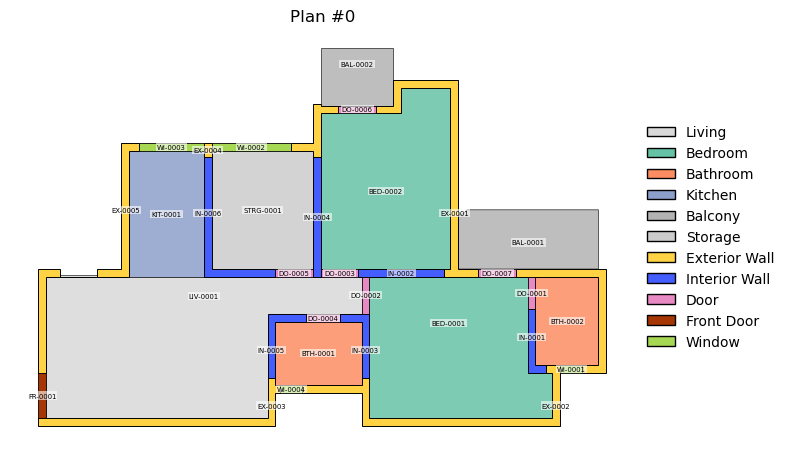

In [7]:
# Assemble artefact and persist JSON/plot outputs
from thesis_package import config
from thesis_package.visualize import plot_plan_json

# Ekspor main artefact (JSON + plot tanpa label)
json_path = config.export_one(plan_idx, raw_plan)
print(f"JSON saved to: {json_path}")

# Bangun nama file untuk plot berlabel dan simpan tampilannya
label_path = config.PLOT_LABEL_DIR / f"plan_{plan_idx:05d}_ids.png"

ax = plot_plan_json(json_path, show_ids=True, figsize=(8, 7))
ax.figure.savefig(label_path, dpi=200, bbox_inches="tight")




In [83]:
import json, random
from pathlib import Path
from thesis_package.synthetic import load_plan, save_plan, generate_variants

plan_path_imp = Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json") #location to save imperfect plans
plan_path_imp.mkdir(parents=True, exist_ok=True)  # ensure directory exists

# pick a plan from the output folder
plan_path = Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/resplan_json/plan_00005.json")
plan = load_plan(plan_path)  # or: plan = json.loads(plan_path.read_text())

# optional: fix the random seed so you can reproduce the same drops
rng = random.Random(42)

# build the four imperfect variants
variants = generate_variants(plan, rng=rng)

# save each variant back to disk
for name, imperfect in variants.items():
    out_path = plan_path_imp / f"{plan_path.stem}_{name}.json"
    save_plan(imperfect, out_path)
    print(f"Saved {name} → {out_path}")



Saved drop_interior_wall → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00005_drop_interior_wall.json
Saved drop_door → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00005_drop_door.json
Saved drop_window → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00005_drop_window.json
Saved drop_all_structural → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00005_drop_all_structural.json


Rendering plan_00005_drop_all_structural.json


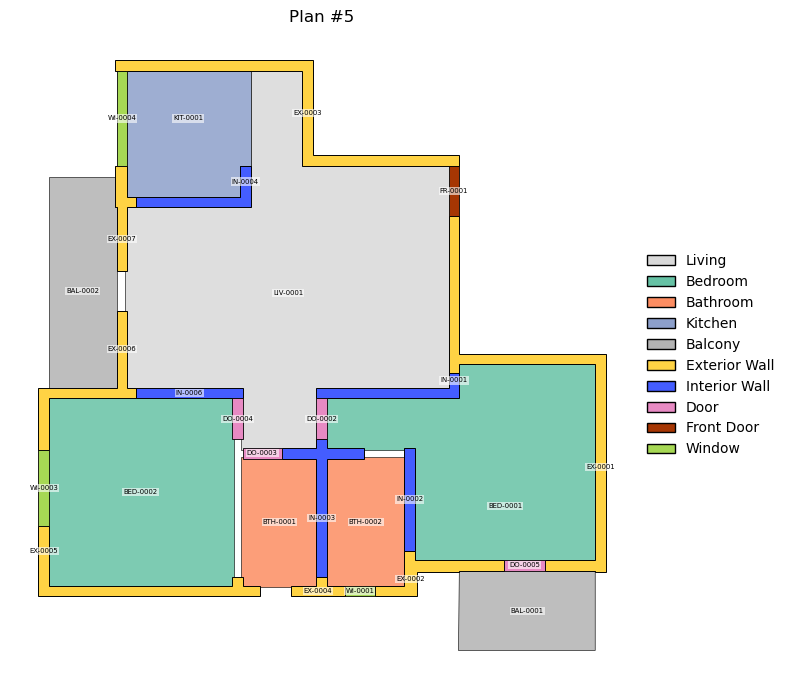

Rendering plan_00005_drop_door.json


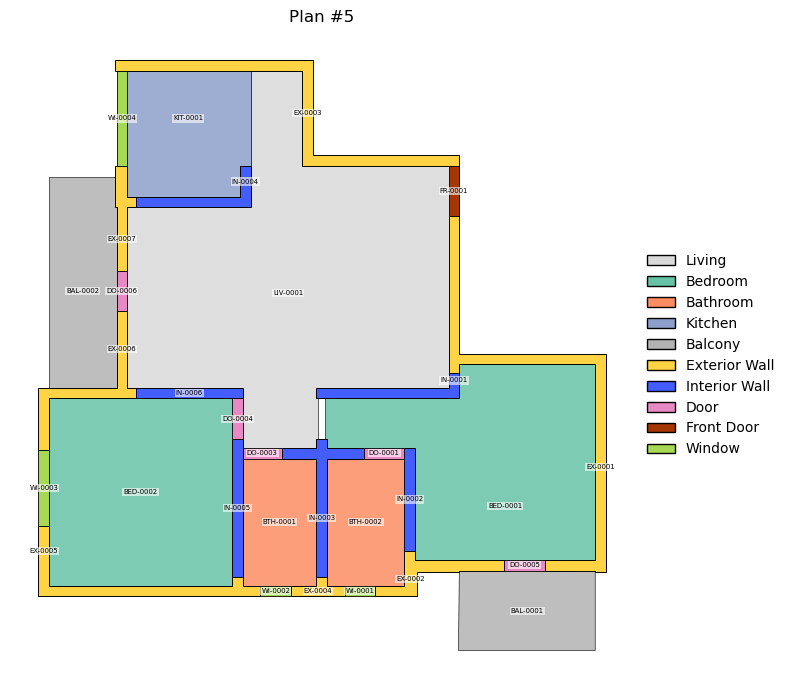

Rendering plan_00005_drop_interior_wall.json


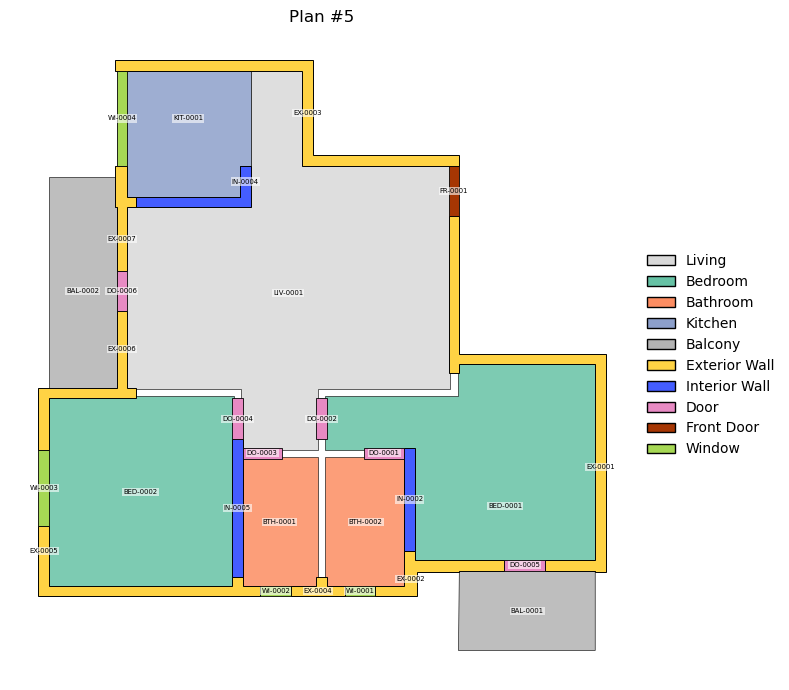

Rendering plan_00005_drop_window.json


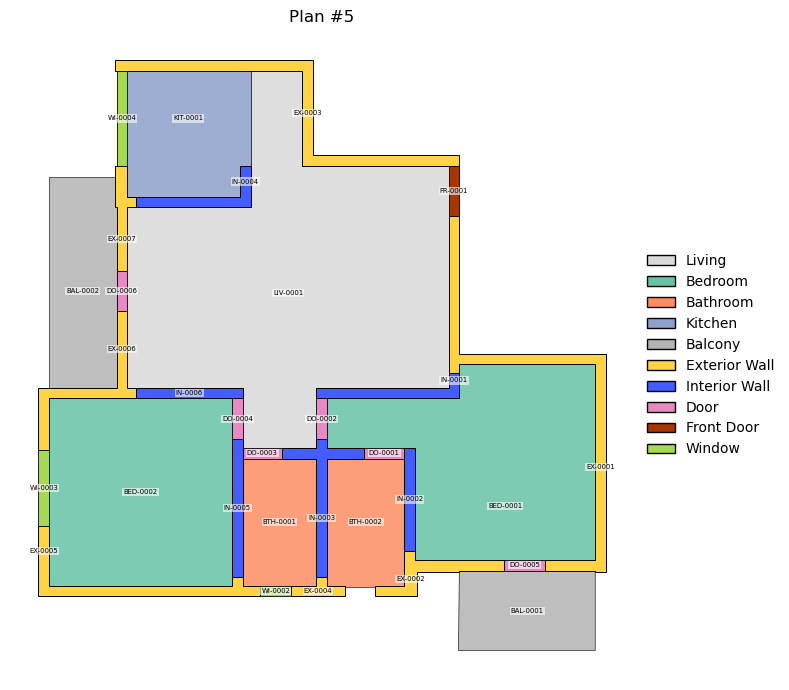

In [80]:
from pathlib import Path
from thesis_package.visualize import plot_plan_json
import matplotlib.pyplot as plt

# folder containing the imperfect plans
variant_dir = Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json")

# list all JSON files you want to inspect
json_paths = sorted(variant_dir.glob("plan_00005_drop_*.json"))

for json_path in json_paths:
    print(f"Rendering {json_path.name}")
    ax = plot_plan_json(json_path, show_ids=True, figsize=(8, 7))
    plt.show()        # display inline
    plt.close(ax.figure)

